<a href="https://colab.research.google.com/github/claramanolache/ML_Intro/blob/main/Week_7_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instructions

For this assignment, you will use the Energy Efficiency dataset to explore and compare different Ensemble Learning methods for regression. Complete all code cells following the provided instructions.

**Do not delete any instructor-provided cells from this Notebook.** If you accidentally delete a cell, you can either undo the action or load a copy of the original assignment Notebook in a new browser tab and copy over the missing cells.

**You can add cells to this Notebook.** To add a markdown (text) cell, hover your cursor beneath the cell where you want to insert and click the "+Text" button. To add a Python (code) cell, click the "+Code" button.

### Steps
- Load and explore the Energy Efficiency dataset.
- Prepare the data by splitting into training and test sets.
- Build and evaluate ensemble regression models: VotingRegressor, RandomForestRegressor, and AdaBoostRegressor.
- Experiment with hyperparameters for each model.
- Compare model performance and report findings about which ensemble methods performed best and what hyperparameters worked well.

## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import ensemble
from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import svm
from sklearn import tree

The following variable will be used to set a random seed for certain processes. Using a seed makes random processes deterministic, meaning this notebook will do things like split data the same way on each run.

You are free to change this value to explore how the notebook runs differently.

In [3]:
seed = 42

## Load the Dataset

The Energy Efficiency dataset was created to assess the heating load and cooling load requirements of buildings as a function of building parameters. This dataset comes from the UCI Machine Learning Repository.

### Features
- **X1**: Relative Compactness
- **X2**: Surface Area
- **X3**: Wall Area
- **X4**: Roof Area
- **X5**: Overall Height
- **X6**: Orientation
- **X7**: Glazing Area
- **X8**: Glazing Area Distribution

### Target Variables
- **Y1**: Heating Load
- **Y2**: Cooling Load

For this assignment, you will predict your choice of either the **Heating Load (Y1)** or **Cooling Load (Y2)** using the eight building features.

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(url)
df.shape

(768, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


### Inspect the Data

Display the first few rows and check for missing values.

In [6]:
df.head(10)

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
5,0.90,563.5,318.5,122.50,7.0,3,0.0,0,21.46,25.38
6,0.90,563.5,318.5,122.50,7.0,4,0.0,0,20.71,25.16
7,0.90,563.5,318.5,122.50,7.0,5,0.0,0,19.68,29.60
8,0.86,588.0,294.0,147.00,7.0,2,0.0,0,19.50,27.30
9,0.86,588.0,294.0,147.00,7.0,3,0.0,0,19.95,21.97


In [7]:
df.isnull().sum()

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
Y1,0
Y2,0


### Display Summary Statistics

In [8]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


## Prepare the Data

### Create a Feature Matrix and Target Vector

Create a feature matrix `X` containing the eight building features (X1 through X8).

Create a target vector `y` containing your choice of either the Heating Load (Y1) or Cooling Load (Y2).

In [9]:
X = df.drop(columns=["Y1", "Y2"])
y = df["Y1"]
X.shape, y.shape

((768, 8), (768,))

### Split into Training and Test Sets

Split the data into training and test sets using a 80/20 split.

Use `train_test_split` from `sklearn.model_selection` with the `seed` variable as the `random_state`.

In [10]:
test_size = 0.2

In [11]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=test_size, random_state=seed
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

## Visualize the Dataset

Create at least one visualization to explore relationships between features and the target variable

Although the use of Generative AI to write code for all other parts of assignments is discouraged, for visualizations - which are not strictly part of a machine learning curriculum - you may use Gemini or another LLM of your choice to write Matplotlib (or Seaborn) code, which may help you better explore the data.

**However, be sure you understand and explain any visualization that is part of your submission.**

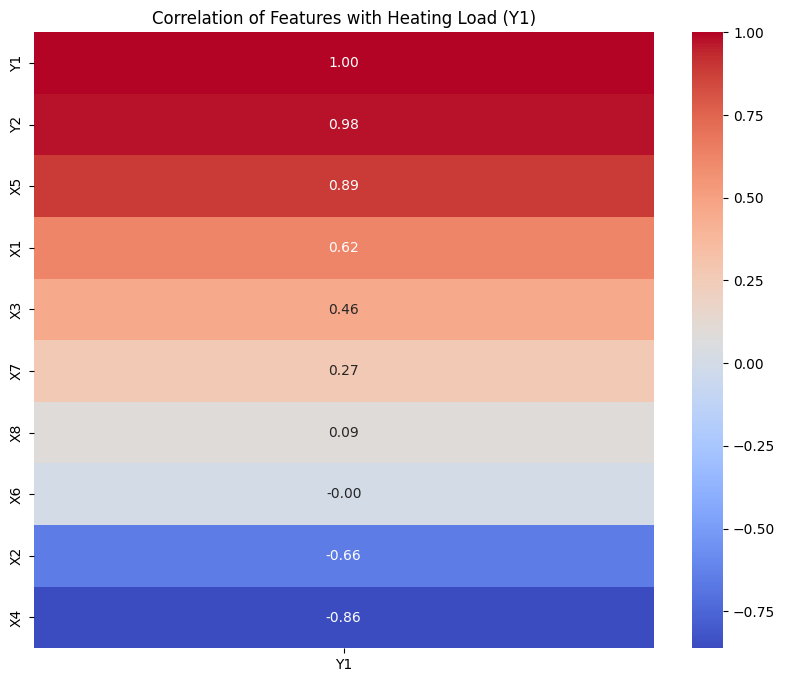

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True)[['Y1']].sort_values(by='Y1', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of Features with Heating Load (Y1)')
plt.show()

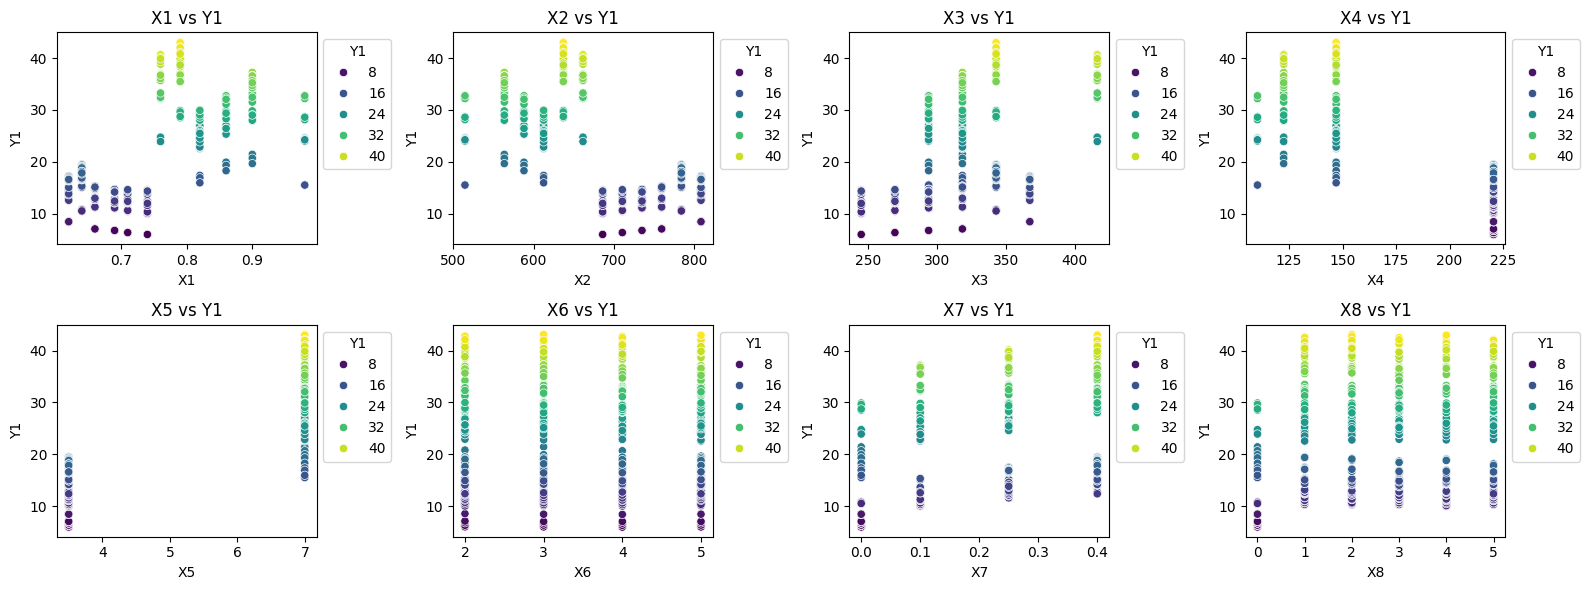

In [13]:
X_features = df.drop(columns=['Y1', 'Y2']).columns
n_features = len(X_features)

n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(X_features):
    sns.scatterplot(data=df, x=col, y='Y1', hue='Y1', palette='viridis', ax=axes[i], legend=True)
    axes[i].set_title(f'{col} vs Y1')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Y1')
    # Customize legend position if needed
    axes[i].legend(title='Y1', loc='upper left', bbox_to_anchor=(1, 1))

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Report Findings

Describe what your visualization(s) represent and what you observe.

From the first graph, we see there is a strong negative correlation between Y1 and both X4 and X2. Simmilarly, there is a strong positive correlation between Y1 and X5. On the other hand, there is very small correlation between Y1 and both X6 and X8, suggesting a non-linear relationship for these variables.

From the scatter plots of each feature against Heating Load, we see that there is some clustering for X1 and X2, which explains why it had a smaller correlation. There is a simmilar clustering with X2 and X4. This suggests that these variables would work well with a decision tree (and therfore random forest).

X3 is somewhat linear, but there is noticable fanning near the end, which explains the correlation of 0.46.

The plots for different orientations, X6, show that Y1 values are distributed quite similarly across all categories, suggesting that orientation has a relatively weak influence on heating load compared to other features. This is somewhat simmilar for X8: except for grazing area of 0, everything is simmilarly dist.

X5 has a very strong relationship. Buildings with an overall height of 3.5 tend to have lower and less variable Y1 values. In contrast, buildings with a height of 7.0 show significantly higher and more spread-out Y1 values, highlighting its substantial impact on heating load.

For a glazing area (X7) of 0.0, Y1 values are generally lower. As the glazing area increases (0.1, 0.25, 0.40), Y1 tends to increase, with distinct clusters for each glazing percentage.



## Build a Voting Regressor

A VotingRegressor combines predictions from multiple regression models by averaging them.

Create a VotingRegressor using at least three base models, such as:
- LinearRegression
- DecisionTreeRegressor
- SVR (Support Vector Machine)

You can use different base models - including the same type of model with different hyperparameters - or more than three models in your VotingRegressor.

### Create and Train the VotingRegressor

Create three base models and combine them using `VotingRegressor` from `sklearn.ensemble`.

Train the voting regressor on the training data.

**Example structure:**
```python
model1 = linear_model.LinearRegression()
model2 = tree.DecisionTreeRegressor(random_state=seed)
model3 = tree.DecisionTreeRegressor(max_depth=5, random_state=seed)

voting_reg = ensemble.VotingRegressor(
    estimators=[("lr", model1), ("dt1", model2), ("dt2", model3)]
)

voting_reg.fit(X_train, y_train)
```

In [14]:
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
model1 = linear_model.LinearRegression()
model2 = tree.DecisionTreeRegressor(random_state=seed)
model3 = svm.SVR(kernel='rbf', C=100)

voting_reg = ensemble.VotingRegressor(
    estimators=[("lr", model1), ("dt1", model2), ("svr", model3)],
)

voting_reg.fit(X_train_scaled, y_train)

VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('dt1', DecisionTreeRegressor(random_state=42)),
                            ('svr', SVR(C=100))])

### Evaluate the VotingRegressor

Make predictions on the test set and calculate the RMSE.

In [38]:
y_pred = voting_reg.predict(X_test_scaled)
metrics.mean_absolute_error(y_test, y_pred)

0.8875735957003265

## Build a Random Forest Regressor

RandomForestRegressor is an ensemble method that builds multiple decision trees and averages their predictions. It uses a technique called bootstrap aggregating (bagging) where each tree is trained on a random sample of the data.

**Note:** You may use ExtraTreesRegressor instead of RandomForestRegressor if you want to try it out. ExtraTreesRegressor is similar but introduces more randomness in how it splits nodes.

### Create and Train a RandomForestRegressor

Create a RandomForestRegressor and train it on the training data.

Start with these hyperparameters, which you can adjust later:
- `n_estimators`: Number of trees in the forest (try 100)
- `max_depth`: Maximum depth of trees (try None or a specific value like 10)
- `min_samples_split`: Minimum samples required to split a node (try 2)
- `random_state`: Use the seed variable

In [18]:
rf_clf = ensemble.RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    random_state=seed
)
rf_clf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

### Evaluate the RandomForestRegressor

Make predictions on the test set and calculate the RMSE.

In [19]:
y_pred_rf = rf_clf.predict(X_test)
metrics.mean_absolute_error(y_test, y_pred_rf)

0.35629201902174246

### Feature Importance

One advantage of Random Forest models is that they can tell us which features are most important for making predictions.

Access the feature importances using the `.feature_importances_` attribute of your trained model. Display the feature importances in a readable format, such as a DataFrame. See this week's Practice Notebook for an example.

In [25]:
tf_columns = X.columns
pd.Series(
    rf_clf.feature_importances_, index=tf_columns
).sort_values(ascending=False).rename("importance")

,importance
X1,0.386447
X2,0.188587
X5,0.151004
X4,0.135531
X7,0.079107
X3,0.046204
X8,0.012426
X6,0.000694


## Build an AdaBoost Regressor

AdaBoostRegressor is an ensemble method that combines multiple weak learners (typically decision trees) in a sequential manner. Each new model focuses on the errors made by previous models, gradually improving overall performance.

**Note:** You may use GradientBoostingRegressor instead of AdaBoostRegressor if you want to try it out.

### Create and Train an AdaBoostRegressor

Create an AdaBoostRegressor and train it on the training data.

Start with these hyperparameters, which you can adjust later:
- `n_estimators`: Number of boosting stages (try 50 or 100)
- `learning_rate`: Controls how much each model contributes (try 1.0)
- `random_state`: Use the seed variable

In [33]:
ada_clf = ensemble.AdaBoostRegressor(
    n_estimators=50,
    learning_rate=1.0,
    random_state=seed
)

ada_clf.fit(X_train, y_train)

AdaBoostRegressor(random_state=42)

### Evaluate the AdaBoostRegressor

Make predictions on the test set and calculate the RMSE.

In [32]:
y_pred_ada = ada_clf.predict(X_test)

ada_accuracy = metrics.mean_squared_error(y_test, y_pred_ada)
print(f"AdaBoost Accuracy: {ada_accuracy:.4f}")

AdaBoost Accuracy: 3.7686


## Compare All Three Ensemble Methods

Now that you have trained and evaluated three different ensemble methods, compare their performance.

Create a DataFrame or visualization showing the RMSE scores for:
- VotingRegressor
- RandomForestRegressor (or ExtraTreesRegressor)
- AdaBoostRegressor (or GradientBoostingRegressor)

In [39]:
rmse_voting = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
rmse_rf = np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf))
rmse_ada = np.sqrt(metrics.mean_squared_error(y_test, y_pred_ada))


comparison_df = pd.DataFrame({
    'Model': ['VotingRegressor', 'RandomForestRegressor', 'AdaBoostRegressor'],
    'RMSE': [rmse_voting, rmse_rf, rmse_ada]
})

print(comparison_df.set_index('Model'))

                           RMSE
Model                          
VotingRegressor        1.238616
RandomForestRegressor  0.493704
AdaBoostRegressor      1.941285


### Report Initial Findings

Based on the comparison above, which ensemble method performed best with the default hyperparameters?

The best ensemble method was the the Random Forest Regressor by far.

## Experiment with Hyperparameters

Now experiment with different hyperparameter values for each ensemble method to see if you can improve performance.

You don't need to try every possible combination - just explore a few different settings that might improve your models based on your understanding of how these algorithms work.

### Experiment with VotingRegressor

Try different combinations of base models or different hyperparameters for the base models.

For example:
- Try using different base models
- Try using `weights` parameter to give more importance to certain models
- Try adjusting hyperparameters of the base models

In [69]:
model1 = linear_model.LinearRegression()
model2 = tree.DecisionTreeRegressor(random_state=seed,max_depth=7,min_samples_leaf=1,min_samples_split=2)
model3 = svm.SVR(kernel='rbf', C=100)
model4 = ensemble.GradientBoostingRegressor(random_state=seed, learning_rate=0.2, max_depth=5, n_estimators=200)

y_pred_1 = model1.fit(X_train_scaled, y_train).predict(X_test_scaled)
y_pred_2 = model2.fit(X_train_scaled, y_train).predict(X_test_scaled)
y_pred_3 = model3.fit(X_train_scaled, y_train).predict(X_test_scaled)
y_pred_4 = model4.fit(X_train_scaled, y_train).predict(X_test_scaled)

rmse_lr = np.sqrt(metrics.mean_squared_error(y_test, y_pred_1))
rmse_dt = np.sqrt(metrics.mean_squared_error(y_test, y_pred_2))
rmse_svr = np.sqrt(metrics.mean_squared_error(y_test, y_pred_3))
rmse_gbr = np.sqrt(metrics.mean_squared_error(y_test, y_pred_4))


voting_reg = ensemble.VotingRegressor(
    estimators=[("lr", model1), ("dt1", model2), ("svr", model3), ("gbr", model4)],
    weights=[0, 0.1, 0.1, 0.8]
)

voting_reg.fit(X_train_scaled, y_train)

y_pred_voting = voting_reg.predict(X_test_scaled)
rmse_voting = np.sqrt(metrics.mean_squared_error(y_test, y_pred_voting))


rmse_df = pd.DataFrame({
    'Model': ['LinearRegression', 'DecisionTreeRegressor', 'SVR', 'GradientBoostingRegressor', 'VotingRegressor'],
    'RMSE': [rmse_lr, rmse_dt, rmse_svr, rmse_gbr, rmse_voting]
})

print(rmse_df.set_index('Model'))

                               RMSE
Model                              
LinearRegression           3.025427
DecisionTreeRegressor      0.565186
SVR                        0.734680
GradientBoostingRegressor  0.415633
VotingRegressor            0.406098


### Experiment with RandomForestRegressor

Try different values for key hyperparameters:
- `n_estimators`: Try values like 50, 100, 200
- `max_depth`: Try values like 5, 10, 15, or None
- `min_samples_split`: Try values like 2, 5, 10
- `min_samples_leaf`: Try values like 1, 2, 4
- `max_features`: Try values like 2, 4, 6

In [74]:
rf_clf = ensemble.RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=6,
    random_state=seed
)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
print(np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf)))

0.48017675553741457


In [70]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [2, 4, 6]
}

rf_regressor = ensemble.RandomForestRegressor(random_state=seed)

grid_search_rf = model_selection.GridSearchCV(
    estimator=rf_regressor,
    param_grid=param_grid_rf,
    cv=5, # Using 5-fold cross-validation
    scoring='neg_mean_squared_error', # GridSearchCV maximizes scores, so we use negative MSE to find the minimum RMSE
    n_jobs=-1 # Use all available cores
)

grid_search_rf.fit(X_train, y_train)

print(f"Best hyperparameters for RandomForestRegressor: {grid_search_rf.best_params_}")

best_rf_model = grid_search_rf.best_estimator_
y_pred_rf_tuned = best_rf_model.predict(X_test)
rmse_rf_tuned = np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf_tuned))

print(f"RMSE with optimized RandomForestRegressor: {rmse_rf_tuned:.4f}")

Best hyperparameters for RandomForestRegressor: {'max_depth': 15, 'max_features': 6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
RMSE with optimized RandomForestRegressor: 0.4802


Visualizing RandomForestRegressor hyperparameter effects...


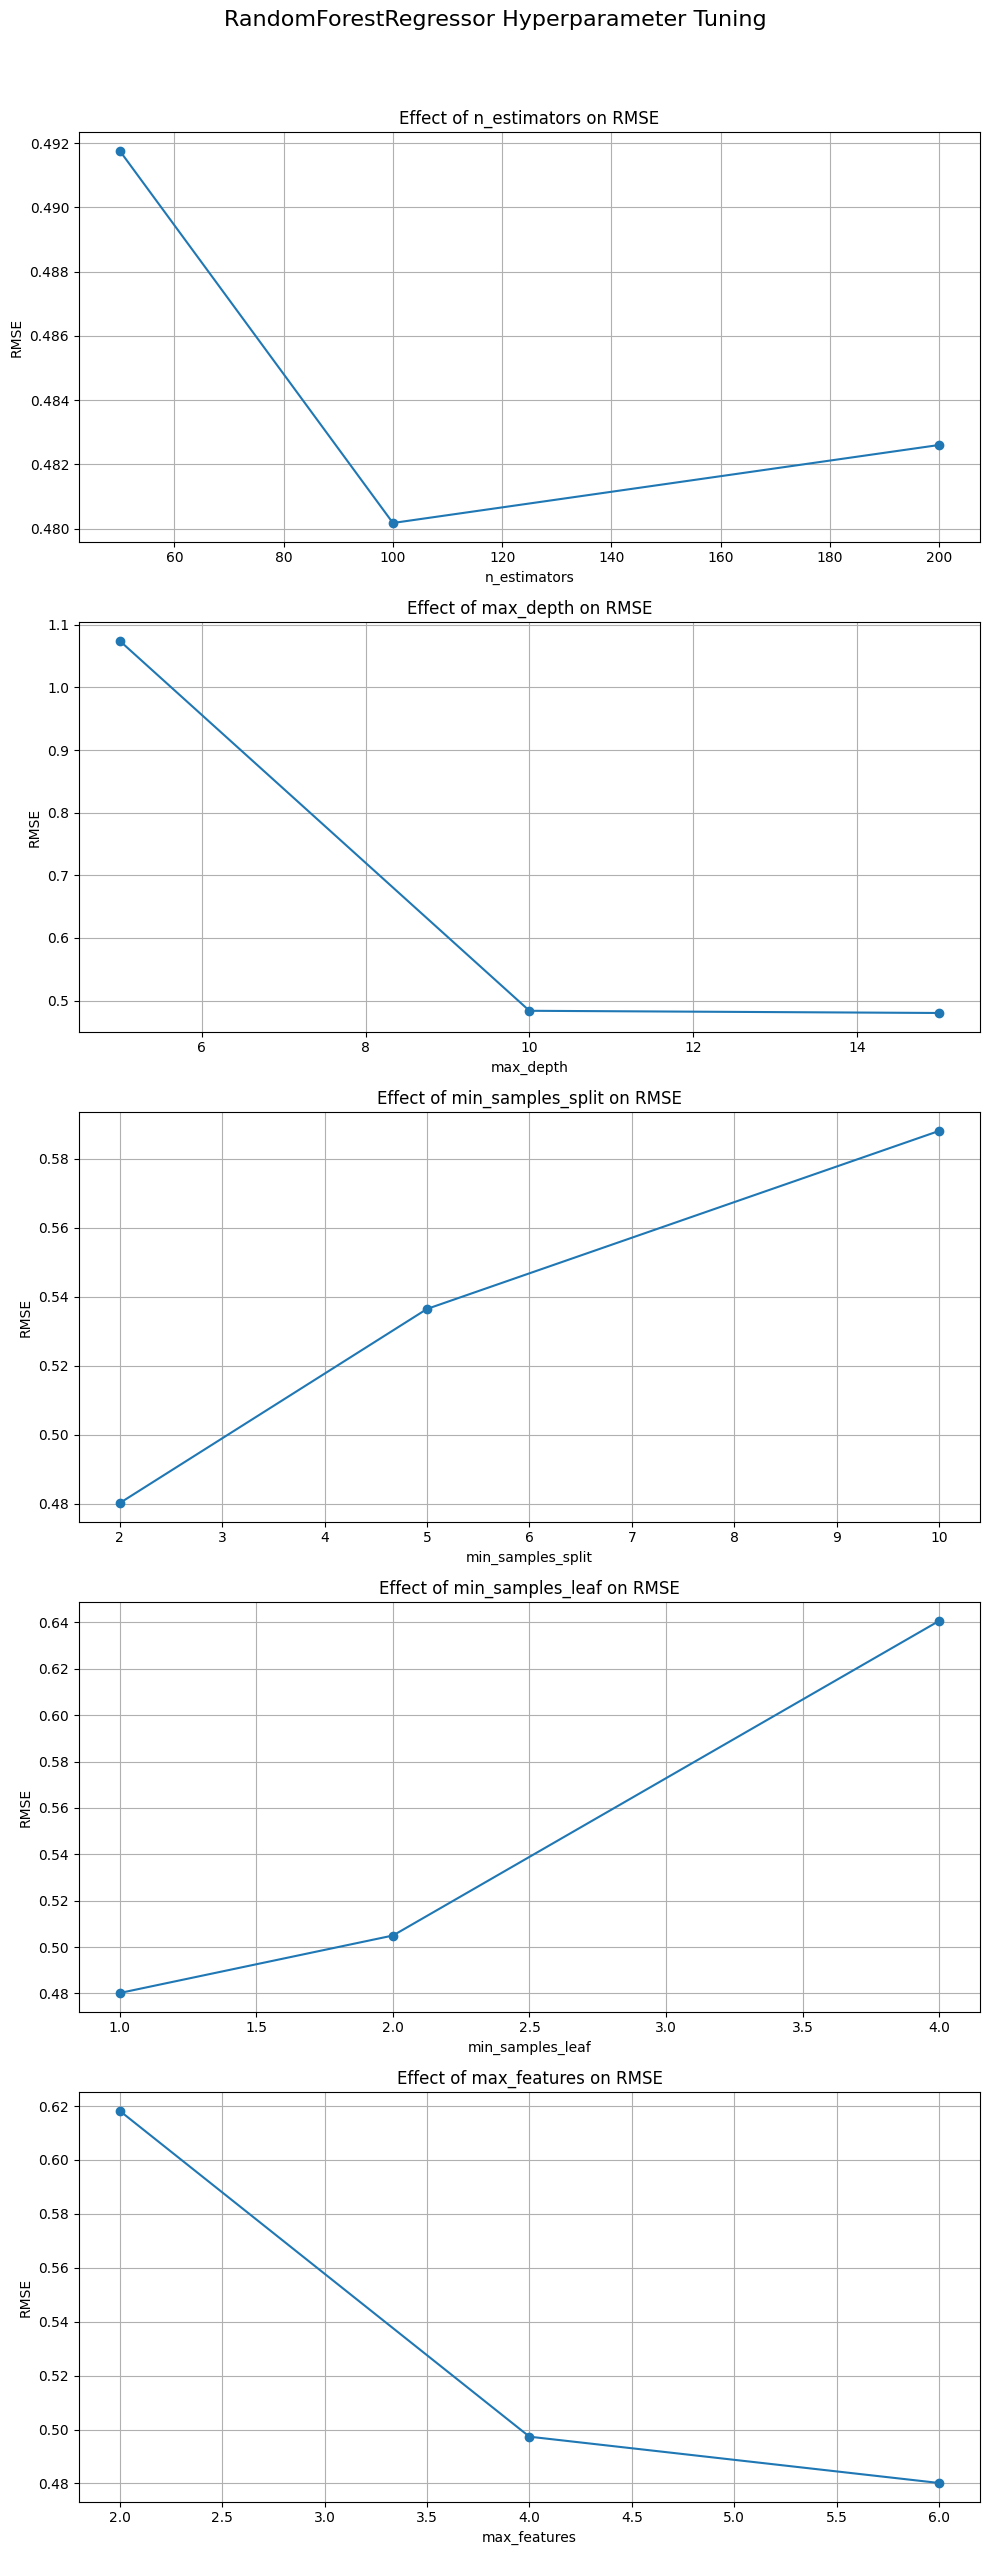


Visualizing AdaBoostRegressor hyperparameter effects...


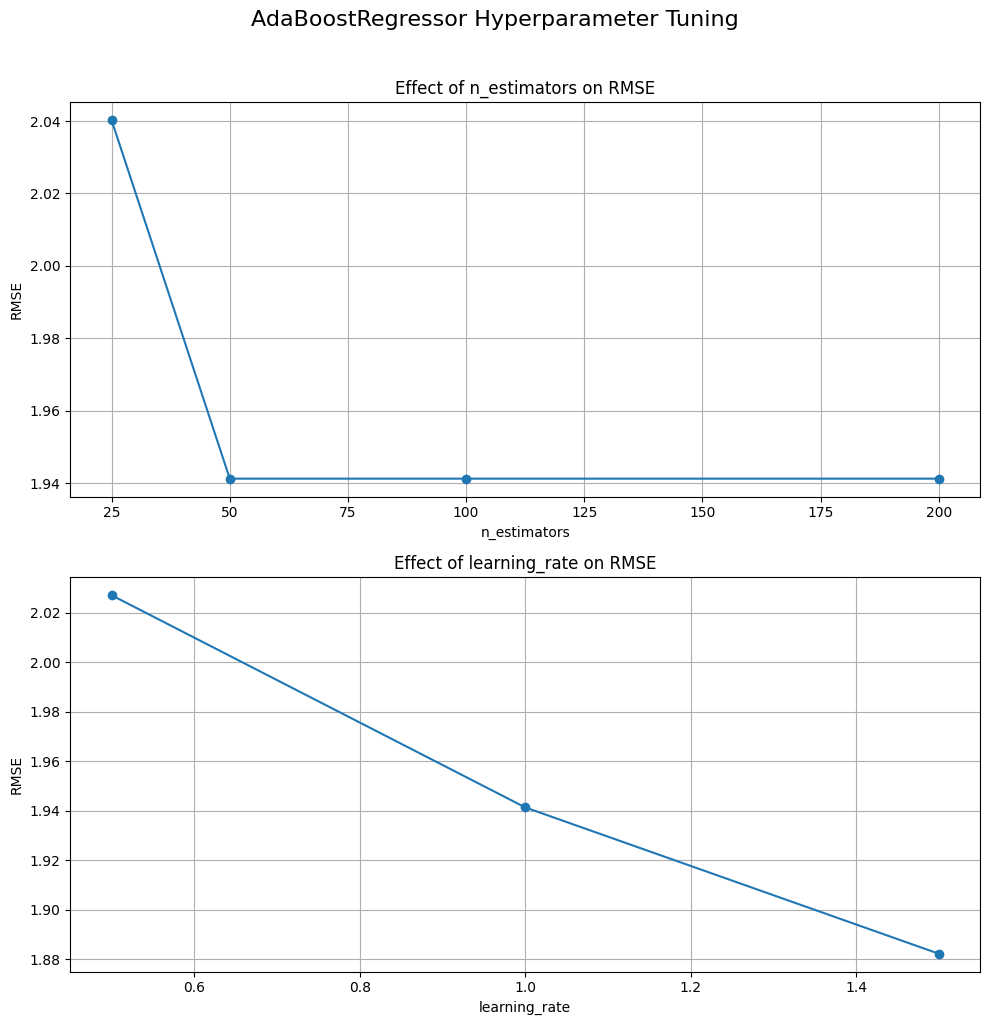

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- RandomForestRegressor Hyperparameter Effect Visualization ---
print("Visualizing RandomForestRegressor hyperparameter effects...")

best_rf_params = grid_search_rf.best_params_

# Store results for plotting
rf_results = {}

# 1. Effect of n_estimators
n_estimators_values = param_grid_rf['n_estimators']
rmse_n_estimators = []
for n_est in n_estimators_values:
    rf_model = ensemble.RandomForestRegressor(
        n_estimators=n_est,
        max_depth=best_rf_params['max_depth'],
        min_samples_split=best_rf_params['min_samples_split'],
        min_samples_leaf=best_rf_params['min_samples_leaf'],
        max_features=best_rf_params['max_features'],
        random_state=seed
    )
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    rmse_n_estimators.append(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
rf_results['n_estimators'] = (n_estimators_values, rmse_n_estimators)

# 2. Effect of max_depth
max_depth_values = [d for d in param_grid_rf['max_depth'] if d is not None] # Exclude None for plotting continuous-like axis
rmse_max_depth = []
for depth in max_depth_values:
    rf_model = ensemble.RandomForestRegressor(
        n_estimators=best_rf_params['n_estimators'],
        max_depth=depth,
        min_samples_split=best_rf_params['min_samples_split'],
        min_samples_leaf=best_rf_params['min_samples_leaf'],
        max_features=best_rf_params['max_features'],
        random_state=seed
    )
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    rmse_max_depth.append(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
rf_results['max_depth'] = (max_depth_values, rmse_max_depth)

# 3. Effect of min_samples_split
min_samples_split_values = param_grid_rf['min_samples_split']
rmse_min_samples_split = []
for mss in min_samples_split_values:
    rf_model = ensemble.RandomForestRegressor(
        n_estimators=best_rf_params['n_estimators'],
        max_depth=best_rf_params['max_depth'],
        min_samples_split=mss,
        min_samples_leaf=best_rf_params['min_samples_leaf'],
        max_features=best_rf_params['max_features'],
        random_state=seed
    )
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    rmse_min_samples_split.append(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
rf_results['min_samples_split'] = (min_samples_split_values, rmse_min_samples_split)

# 4. Effect of min_samples_leaf
min_samples_leaf_values = param_grid_rf['min_samples_leaf']
rmse_min_samples_leaf = []
for msl in min_samples_leaf_values:
    rf_model = ensemble.RandomForestRegressor(
        n_estimators=best_rf_params['n_estimators'],
        max_depth=best_rf_params['max_depth'],
        min_samples_split=best_rf_params['min_samples_split'],
        min_samples_leaf=msl,
        max_features=best_rf_params['max_features'],
        random_state=seed
    )
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    rmse_min_samples_leaf.append(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
rf_results['min_samples_leaf'] = (min_samples_leaf_values, rmse_min_samples_leaf)

# 5. Effect of max_features
max_features_values = param_grid_rf['max_features']
rmse_max_features = []
for mf in max_features_values:
    rf_model = ensemble.RandomForestRegressor(
        n_estimators=best_rf_params['n_estimators'],
        max_depth=best_rf_params['max_depth'],
        min_samples_split=best_rf_params['min_samples_split'],
        min_samples_leaf=best_rf_params['min_samples_leaf'],
        max_features=mf,
        random_state=seed
    )
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    rmse_max_features.append(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
rf_results['max_features'] = (max_features_values, rmse_max_features)


# Plotting RandomForestRegressor results
fig, axes = plt.subplots(len(rf_results), 1, figsize=(10, 5 * len(rf_results)))
fig.suptitle('RandomForestRegressor Hyperparameter Tuning', y=1.02, fontsize=16)

for i, (param_name, (values, rmses)) in enumerate(rf_results.items()):
    axes[i].plot(values, rmses, marker='o')
    axes[i].set_xlabel(param_name)
    axes[i].set_ylabel('RMSE')
    axes[i].set_title(f'Effect of {param_name} on RMSE')
    axes[i].grid(True)
plt.tight_layout()
plt.show()


# --- AdaBoostRegressor Hyperparameter Effect Visualization ---
print("\nVisualizing AdaBoostRegressor hyperparameter effects...")

# Define parameter grids for AdaBoost (based on previous suggestions)
param_grid_ada = {
    'n_estimators': [25, 50, 100, 200],
    'learning_rate': [0.5, 1.0, 1.5]
}

# AdaBoost defaults (from ada_03 for n_estimators, ada_07 for learning_rate initial exploration)
default_ada_n_estimators = 50
default_ada_learning_rate = 1.0

ada_results = {}

# 1. Effect of n_estimators
n_estimators_ada_values = param_grid_ada['n_estimators']
rmse_n_estimators_ada = []
for n_est in n_estimators_ada_values:
    ada_model = ensemble.AdaBoostRegressor(
        n_estimators=n_est,
        learning_rate=default_ada_learning_rate,
        random_state=seed
    )
    ada_model.fit(X_train, y_train)
    y_pred = ada_model.predict(X_test)
    rmse_n_estimators_ada.append(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
ada_results['n_estimators'] = (n_estimators_ada_values, rmse_n_estimators_ada)

# 2. Effect of learning_rate
learning_rate_values = param_grid_ada['learning_rate']
rmse_learning_rate_ada = []
for lr in learning_rate_values:
    ada_model = ensemble.AdaBoostRegressor(
        n_estimators=default_ada_n_estimators,
        learning_rate=lr,
        random_state=seed
    )
    ada_model.fit(X_train, y_train)
    y_pred = ada_model.predict(X_test)
    rmse_learning_rate_ada.append(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
ada_results['learning_rate'] = (learning_rate_values, rmse_learning_rate_ada)

# Plotting AdaBoostRegressor results
fig, axes = plt.subplots(len(ada_results), 1, figsize=(10, 5 * len(ada_results)))
fig.suptitle('AdaBoostRegressor Hyperparameter Tuning', y=1.02, fontsize=16)

for i, (param_name, (values, rmses)) in enumerate(ada_results.items()):
    axes[i].plot(values, rmses, marker='o')
    axes[i].set_xlabel(param_name)
    axes[i].set_ylabel('RMSE')
    axes[i].set_title(f'Effect of {param_name} on RMSE')
    axes[i].grid(True)
plt.tight_layout()
plt.show()

### Experiment with AdaBoostRegressor

Try different values for key hyperparameters:
- `n_estimators`: Try values like 50, 100, 200
- `learning_rate`: Try values like 0.5, 1.0, 1.5
- You can also specify a custom `base_estimator` (the weak learner to use)

In [106]:
ada_clf = ensemble.AdaBoostRegressor(
    n_estimators=25,
    learning_rate=1.5,
    random_state=seed
)

ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_test)

ada_accuracy = np.sqrt(metrics.mean_squared_error(y_test, y_pred_ada))
print(f"AdaBoost Accuracy: {ada_accuracy:.4f}")

AdaBoost Accuracy: 1.8182


## Final Comparison and Reflection

### Self-Check

- Which ensemble method performed best overall?
- Did any model perform particularly well or poorly in specific aspects?
- How did the ensemble methods compare to each other?

The best method was the voting, but it depends on the individual models within. Adding the gradient and changing the weights really helped improve the accuracy (from 1.2 to .4). But overall, I think the Random Forest was a very good method, beacause even at its defualt it was preforming very well and there was very small change between the defualt and the tuned Forest. Ada boost kinda sucks, but I think its just not the right base model.

### Report Findings: Hyperparameters

Consider the following questions about hyperparameter tuning to report your findings. You do not need to answer every one, and you are welcome to explain interesting results from specific hyperparameters aside from what is listed here.

1. **For VotingRegressor:**
   - What combination of base models worked best?
   - Did using `weights` improve performance?

2. **For RandomForestRegressor:**
   - Which hyperparameters had the biggest impact on performance?
   - What were the best values you found for `n_estimators` and `max_depth`?

3. **For AdaBoostRegressor:**
   - How did changing `n_estimators` affect performance?
   - What `learning_rate` worked best?
   - Did you notice any overfitting with certain hyperparameter settings?

# Answers

1.  I checked the individual models preformances to determine the best weight. Obviously, the model with the best preformance had a much bigger vote, but by adding other votes, the accuracy of the overall model was much better. I tried to add ridge and lasso, but they didn't improve much.

2. I actually modified some code I found on the internet to create a grid of models with all hyperparameter combinations and then found the best one within. But the change was so small that it wasn't worth the 6 minute compilation time. I then used AI to visualize the changes for each change, because I thought it would be intresting to see. Here are some of my observations:


*   For n_estimators, there is a steep decrease from 50 to 100, but relativly shallow to 200. This suggests that 100 is optimal because it balances preformance and knowlege
*   For max depth, there is relativly no difference betwen 10 and 15, so this is probably a good spot before overfitting
*   For Min sample split and min_sample_leaf, there appears to be a non-linear possitive accosiation (meaning it gets worse as min_sample split increases). However, sample_split resembles a sqrt graph but sample_leaf looks expontial.



3. The n_estimators made a very small preformance effect, nothing more than a percentage. The learning rate, on the other hand, had the biggest effect on accuracy. I did notice some overfitting, especially getting to the hundreds. Suprisingly, the best preformance was with 25. And at 30, the preformance pretty much flatlines. I think past this point it is overfitting. At 20 however, there is underfitting because the preformance gets much worse—even worse than the hundreds (RMSE of like 2).